In [2]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Float
from smac import Scenario, BlackBoxFacade

SEED = 67
N_TRIALS = 100
OUTPUT_DIRECTORY = "smac3_output"


def branin_value(x1, x2):
    """Branin-Hoo function. Global minimum is about 0.397887."""
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r) ** 2 + s * (1.0 - t) * np.cos(x1) + s


def target_function(config, seed=0):
    """SMAC target function. SMAC minimizes this value."""
    x1 = config["x1"]
    x2 = config["x2"]
    return branin_value(x1, x2)


# -----------------------------
# 1. Configuration space
# -----------------------------
cs = ConfigurationSpace(seed=SEED)

cs.add([
    Float("x1", bounds=(-5.0, 10.0)),
    Float("x2", bounds=(0.0, 15.0)),
])


# -----------------------------
# 2. Scenario
# -----------------------------
scenario = Scenario(
    configspace=cs,
    name="branin_100_trials",
    output_directory=OUTPUT_DIRECTORY,
    deterministic=True,
    n_trials=N_TRIALS,
    seed=SEED,
)


# -----------------------------
# 3. SMAC optimizer
# -----------------------------
smac = BlackBoxFacade(
    scenario=scenario,
    target_function=target_function,
    overwrite=True,
)


# -----------------------------
# 4. Run optimization
# -----------------------------
incumbent = smac.optimize()
incumbent_cost = smac.runhistory.get_cost(incumbent)

print("\nBest configuration:")
print(dict(incumbent))
print(f"Best cost: {incumbent_cost:.8f}")

run_dir = Path(scenario.output_directory) / scenario.name / str(scenario.seed)
print("\nSMAC output directory:")
print(run_dir.resolve())


[INFO][abstract_initial_design.py:143] Using 16 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config f23915 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config bb7619 and rejected config f23915 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config a2b59e and rejected config bb7619 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config b0a7f9 and rejected config a2b59e as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 24aec9 and rejected config b0a7f9 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config bfaf32 and rej


Running SMAC with seed 0
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 16 to 7 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 7 initial design configurations and 0 additional configurations.


[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Seed 0: x1=3.128771, x2=2.312992, cost=0.39945901

Running SMAC with seed 1
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 16 to 7 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 7 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Seed 1: x1=3.106729, x2=2.434320, cost=0.42113953

Running SMAC with seed 2
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 16 to 7 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 7 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returni

C:\Users\felix\AppData\Local\Temp\ipykernel_16776\585828537.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(final_costs, labels=["SMAC"])


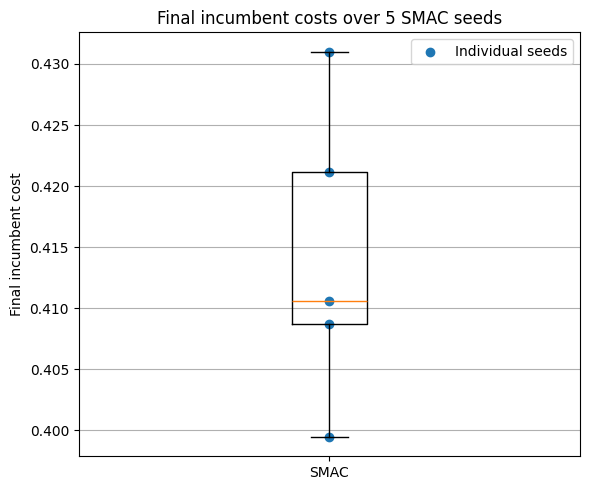

C:\Users\felix\AppData\Local\Temp\ipykernel_16776\585828537.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([final_x1, final_x2], labels=["x1", "x2"])


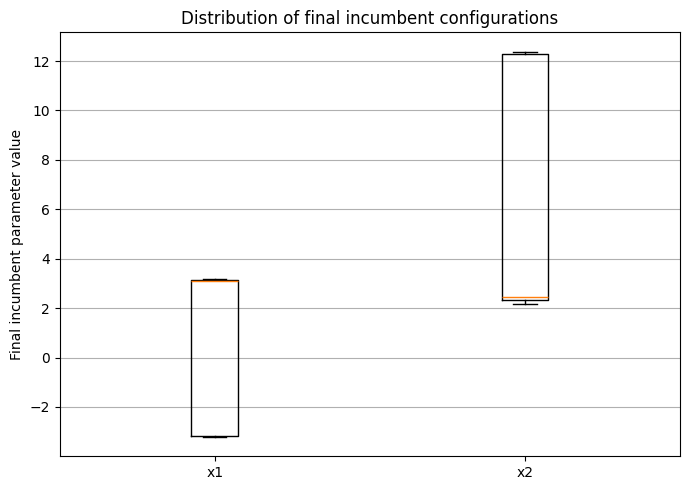

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Float
from smac import Scenario, BlackBoxFacade


N_TRIALS = 30
SEEDS = range(5)
OUTPUT_DIRECTORY = "smac3_output"


def branin_value(x1, x2):
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r) ** 2 + s * (1.0 - t) * np.cos(x1) + s


def target_function(config, seed=0):
    x1 = config["x1"]
    x2 = config["x2"]
    return branin_value(x1, x2)


results = []

for smac_seed in SEEDS:
    print(f"\nRunning SMAC with seed {smac_seed}")

    cs = ConfigurationSpace(seed=smac_seed)
    cs.add([
        Float("x1", bounds=(-5.0, 10.0)),
        Float("x2", bounds=(0.0, 15.0)),
    ])

    scenario = Scenario(
        configspace=cs,
        name="branin_100_trials_10_seeds",
        output_directory=OUTPUT_DIRECTORY,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=smac_seed,
    )

    smac = BlackBoxFacade(
        scenario=scenario,
        target_function=target_function,
        #overwrite=True,
    )

    incumbent = smac.optimize()
    incumbent_cost = smac.runhistory.get_cost(incumbent)

    results.append({
        "seed": smac_seed,
        "x1": incumbent["x1"],
        "x2": incumbent["x2"],
        "cost": incumbent_cost,
    })

    print(
        f"Seed {smac_seed}: "
        f"x1={incumbent['x1']:.6f}, "
        f"x2={incumbent['x2']:.6f}, "
        f"cost={incumbent_cost:.8f}"
    )


# Convert results to arrays
final_costs = np.array([r["cost"] for r in results])
final_x1 = np.array([r["x1"] for r in results])
final_x2 = np.array([r["x2"] for r in results])


print("\nFinal incumbent results:")
for r in results:
    print(
        f"seed={r['seed']:02d} | "
        f"x1={r['x1']:.6f} | "
        f"x2={r['x2']:.6f} | "
        f"cost={r['cost']:.8f}"
    )


print("\nSummary:")
print(f"Mean final incumbent cost:   {np.mean(final_costs):.8f}")
print(f"Median final incumbent cost: {np.median(final_costs):.8f}")
print(f"Std final incumbent cost:    {np.std(final_costs):.8f}")
print(f"Best final incumbent cost:   {np.min(final_costs):.8f}")
print(f"Worst final incumbent cost:  {np.max(final_costs):.8f}")


# Boxplot of final incumbent costs
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(final_costs, labels=["SMAC"])
ax.scatter(
    np.ones(len(final_costs)),
    final_costs,
    marker="o",
    label="Individual seeds",
)

ax.set_ylabel("Final incumbent cost")
ax.set_title(f"Final incumbent costs over {len(SEEDS)} SMAC seeds")
ax.grid(True, axis="y")
ax.legend()

fig.tight_layout()
plt.show()


# Optional: boxplot of final incumbent x1 and x2 values
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot([final_x1, final_x2], labels=["x1", "x2"])

ax.set_ylabel("Final incumbent parameter value")
ax.set_title("Distribution of final incumbent configurations")
ax.grid(True, axis="y")

fig.tight_layout()
plt.show()